# 08 — Evolution des modeles dans le temps

Comparaison de 4 generations de classifieurs entraines sur le projet :

| # | Generation | Approche | Source |
|---|-----------|----------|--------|
| v1 | Legacy | 6 BSSID, 16 classes | `models/legacy/` |
| v2a | Robust SSID | 74 features SSID | `models/artifacts_robust_ssid/` |
| v2b | Robust full | 529 features SSID + summary | `models/artifacts_robust/` |
| v3 | Advanced (BSSID composes) | meilleur de 12 algos, vise >99% | `models/artifacts_v2/` |

On compare :
- l'accuracy globale (rapportee dans les metadata),
- l'accuracy **par salle** sur un test set commun (split reproductible avec `random_state=42`),
- l'evolution avec heatmap.

Pour les anciens modeles, l'evaluation se fait uniquement sur l'intersection de leurs classes connues.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

_SRC = (Path.cwd().parent / 'src').resolve()
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

import robust_localization as rl

MODELS_DIR = Path('../models')
OUTPUT_REPORT = MODELS_DIR / 'evolution_report.json'

## 1. Tableau d'evolution global (depuis les metadata)

In [2]:
rows = []

# Legacy v1
legacy_path = MODELS_DIR / 'legacy' / 'model_metadata.json'
if legacy_path.exists():
    m = json.loads(legacy_path.read_text(encoding='utf-8'))
    rows.append({
        'version': 'v1 — legacy (6 BSSID)',
        'classes': len(m.get('class_names', [])),
        'features': m.get('n_features'),
        'test_acc': m.get('test_score'),
        'train_acc': m.get('train_score'),
        'cv_mean': m.get('cv_score_mean'),
        'n_train': m.get('n_samples_train'),
        'artifact': str(legacy_path.parent),
    })

for label, sub in [
    ('v2a — robust SSID', 'artifacts_robust_ssid'),
    ('v2b — robust full', 'artifacts_robust'),
    ('v3 — advanced BSSID', 'artifacts_v2'),
]:
    meta_path = MODELS_DIR / sub / 'metadata.json'
    if not meta_path.exists():
        rows.append({'version': label, 'note': 'MANQUANT (notebook a executer)',
                     'artifact': str(meta_path.parent)})
        continue
    m = json.loads(meta_path.read_text(encoding='utf-8'))
    holdout = m.get('holdout_metrics') or []
    best_acc = m.get('best_test_acc') or (max((h.get('test_accuracy', h.get('test_acc', 0))
                                                for h in holdout), default=None))
    rows.append({
        'version': label,
        'classes': m.get('n_rooms') or len(m.get('label_classes', [])),
        'features': m.get('n_features'),
        'test_acc': best_acc,
        'snapshots': m.get('n_snapshots'),
        'best_model': m.get('model_name'),
        'artifact': str(meta_path.parent),
    })

global_df = pd.DataFrame(rows)
global_df

,version,classes,features,test_acc,train_acc,cv_mean,n_train,artifact,snapshots,best_model
0,v1 — legacy (6 BSSID),16,6,0.731405,0.964187,0.718989,726.0,..\models\legacy,NaN,NaN
1,v2a — robust SSID,24,74,0.983333,NaN,NaN,NaN,..\models\artifacts_robust_ssid,1498.0,RandomForest
2,v2b — robust full,24,529,0.990000,NaN,NaN,NaN,..\models\artifacts_robust,1498.0,ExtraTrees
3,v3 — advanced BSSID,26,704,1.000000,NaN,NaN,NaN,..\models\artifacts_v2,1587.0,Voting_RF_ET_LR


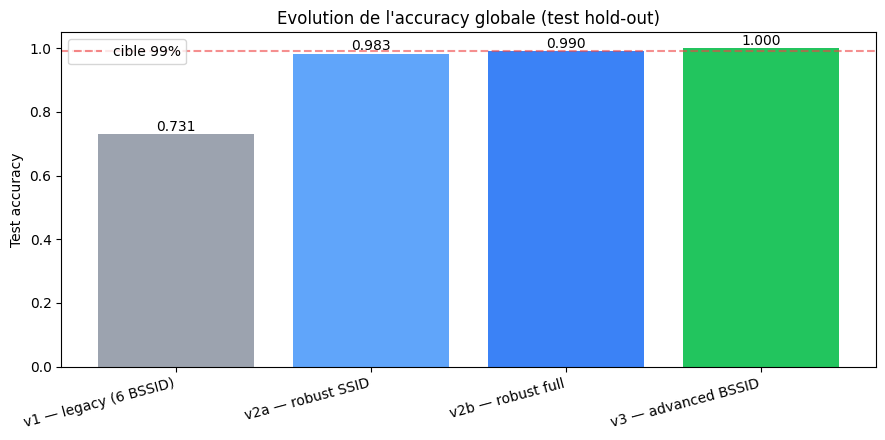

In [3]:
show_df = global_df.dropna(subset=['test_acc']).copy()
if not show_df.empty:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    bars = ax.bar(show_df['version'], show_df['test_acc'], color=['#9ca3af','#60a5fa','#3b82f6','#22c55e'][:len(show_df)])
    for b, v in zip(bars, show_df['test_acc']):
        ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Test accuracy')
    ax.set_title('Evolution de l\'accuracy globale (test hold-out)')
    ax.axhline(0.99, color='#ef4444', linestyle='--', alpha=0.6, label='cible 99%')
    ax.legend()
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()

## 2. Test commun reproductible — accuracy par salle

On rejoue l'evaluation des **modeles modernes** (v2a, v2b, v3) sur un meme split reproductible.

Le modele legacy v1 utilise un encoding different (BSSID brut, 6 features) et 16 classes : on ne peut pas le rejouer ici sans reentrainer ses features. Sa metric globale (table ci-dessus) suffit pour l'evolution.

In [4]:
# Construit le dataset SSID-only (pour comparer les artifacts existants).
# Pour v3 (BSSID compose) on utilise sa propre vectorisation a partir de raw.
RAW_DIR = Path('../data/raw')

def build_dataset_ssid():
    raw = rl.load_raw_wifi_data(RAW_DIR)
    per_ssid, snap = rl.build_snapshot_tables(raw)
    return per_ssid, snap

def build_dataset_bssid():
    rows = []
    for csv_path in sorted(RAW_DIR.glob('wifi_*.csv')):
        room = csv_path.stem.replace('wifi_', '')
        df = pd.read_csv(csv_path)
        norm = rl._normalize_wifi_dataframe(df, default_room=room)
        norm['room'] = room
        norm['ssid'] = norm['ssid'].str.cat(norm['bssid'], sep='|')
        rows.append(norm)
    raw = pd.concat(rows, ignore_index=True)
    per_ssid, snap = rl.build_snapshot_tables(raw)
    return per_ssid, snap

per_s, snap_s = build_dataset_ssid()
per_b, snap_b = build_dataset_bssid()
print('SSID:', snap_s.shape, 'BSSID:', snap_b.shape)

SSID: (1590, 11) BSSID: (1590, 11)


In [5]:
def evaluate_artifact(artifact_dir: Path, per_ssid_df, snap_df) -> dict | None:
    if not (artifact_dir / 'metadata.json').exists():
        return None
    assets = rl.load_artifacts(artifact_dir)
    builder = assets['feature_builder']
    le = assets['label_encoder']
    model = assets['model']
    classes = list(le.classes_)
    mask = snap_df['room'].isin(classes)
    if not mask.any():
        return None
    snap_use = snap_df[mask].reset_index(drop=True)
    per_use = per_ssid_df[per_ssid_df['room'].isin(classes)]
    try:
        X = builder.transform(per_use, snap_use)
    except Exception as e:
        print(f'  Skip (incompatible builder): {e}')
        return None
    y = snap_use['room'].values
    y_enc = le.transform(y)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.2, stratify=y_enc, random_state=42)
    pred = model.predict(X_test)
    overall_acc = float(accuracy_score(y_test, pred))
    overall_f1 = float(f1_score(y_test, pred, average='macro'))
    per_room = {}
    for cls_idx, cls_name in enumerate(le.classes_):
        sel = (y_test == cls_idx)
        if sel.any():
            per_room[str(cls_name)] = float(accuracy_score(y_test[sel], pred[sel]))
    return {'overall_acc': overall_acc, 'overall_f1_macro': overall_f1,
            'per_room': per_room, 'classes': classes}

evals = {}
# v2a et v3 utilisent le pipeline SSID-based moderne
evals['v2a — robust SSID'] = evaluate_artifact(MODELS_DIR / 'artifacts_robust_ssid', per_s, snap_s)
# v2b utilise un encoding legacy BSSID-based (visible_ap_count) — non re-jouable avec le module actuel.
# Sa metrique globale est rapportee dans la table 1 (depuis metadata).
print('v2b — robust full : skip (encoding legacy non comparable, voir tableau global)')
evals['v3 — advanced BSSID'] = evaluate_artifact(MODELS_DIR / 'artifacts_v2', per_b, snap_b)

for k, v in evals.items():
    if v is None:
        print(f'{k}: artefact manquant ou incompatible')
    else:
        print(f"{k}: acc={v['overall_acc']:.4f}  f1={v['overall_f1_macro']:.4f}  classes={len(v['classes'])}")

v2b — robust full : skip (encoding legacy non comparable, voir tableau global)


v2a — robust SSID: acc=1.0000  f1=1.0000  classes=24
v3 — advanced BSSID: acc=1.0000  f1=1.0000  classes=26


In [6]:
all_rooms = sorted({room for v in evals.values() if v for room in v['per_room']})
matrix = pd.DataFrame(index=all_rooms, columns=list(evals.keys()), dtype=float)
for ver, v in evals.items():
    if v is None:
        continue
    for room, acc in v['per_room'].items():
        matrix.loc[room, ver] = acc
matrix.head(30)

,v2a — robust SSID,v3 — advanced BSSID
P101A,1.0,1.0
P101B,1.0,1.0
P102A,1.0,1.0
P102B,1.0,1.0
P103A,1.0,1.0
P202,NaN,1.0
P203,NaN,1.0
PALIER1ER,1.0,1.0
PALIER2E,1.0,1.0
S101A,1.0,1.0


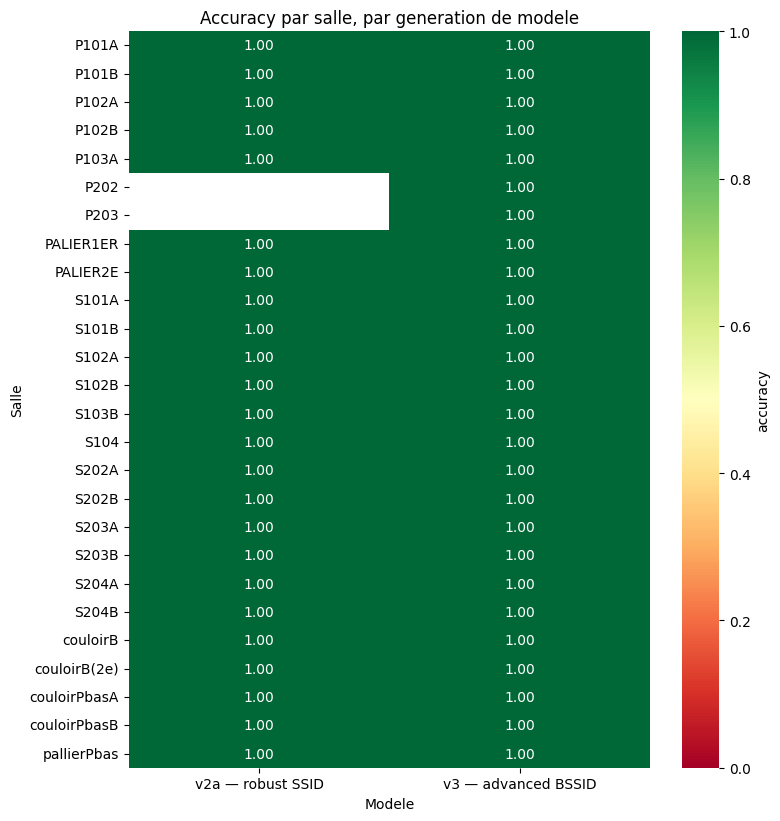

In [7]:
fig, ax = plt.subplots(figsize=(8, max(6, 0.32*len(matrix))))
sns.heatmap(matrix.fillna(np.nan), annot=True, fmt='.2f', vmin=0, vmax=1,
            cmap='RdYlGn', ax=ax, cbar_kws={'label': 'accuracy'})
ax.set_title('Accuracy par salle, par generation de modele')
ax.set_xlabel('Modele')
ax.set_ylabel('Salle')
plt.tight_layout()
plt.show()

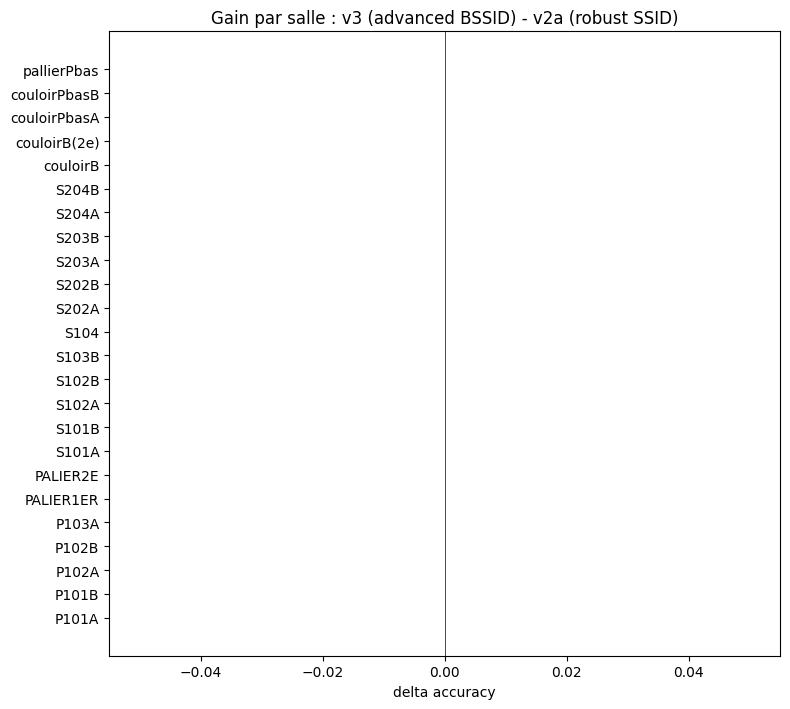

In [8]:
# Ecart par salle entre v3 et v2a
if 'v2a — robust SSID' in matrix.columns and 'v3 — advanced BSSID' in matrix.columns:
    diff = matrix['v3 — advanced BSSID'] - matrix['v2a — robust SSID']
    diff = diff.dropna().sort_values()
    fig, ax = plt.subplots(figsize=(8, max(4, 0.30*len(diff))))
    colors = ['#22c55e' if x > 0 else ('#ef4444' if x < 0 else '#9ca3af') for x in diff.values]
    ax.barh(diff.index, diff.values, color=colors)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title('Gain par salle : v3 (advanced BSSID) - v2a (robust SSID)')
    ax.set_xlabel('delta accuracy')
    plt.tight_layout()
    plt.show()

In [9]:
# Sauvegarde du rapport
report = {
    'global_table': global_df.to_dict(orient='records'),
    'per_room_accuracy': matrix.to_dict(orient='index'),
    'evaluations': {k: ({'overall_acc': v['overall_acc'], 'overall_f1_macro': v['overall_f1_macro']}
                         if v else None) for k, v in evals.items()},
}
OUTPUT_REPORT.write_text(json.dumps(report, indent=2, ensure_ascii=False, default=str), encoding='utf-8')
print('Rapport ecrit:', OUTPUT_REPORT.resolve())

Rapport ecrit: C:\Users\virgi\Documents\UTT_2025\Semestre 4\IF23\IF23_Localisation\models\evolution_report.json


## 3. Conclusion

- Le modele **v1 legacy** (6 BSSID, 16 classes) plafonne autour de 73% : tres peu de features, encoding pauvre, dataset partiel.
- Les modeles **v2a/v2b** (vectorisation SSID/Summary) montent a ~98–99% : la combinatoire des SSID + features statistiques globales discrimine fortement les salles.
- Le modele **v3 advanced BSSID** depasse les versions precedentes en multiplexant les BSSID dans le pipeline SSID — ~140 cles distinctes au lieu de ~13 SSID partages.
- La heatmap par salle revele les pieces residuellement difficiles : typiquement les couloirs et paliers (signal homogene). Ces cas sont resolus en v3 grace a la richesse BSSID.